In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import matplotlib
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/208.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/333.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/45.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/56.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/89.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/20.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/275.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/212.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/239.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/58.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/150.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/6.jpg
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal/1

In [9]:
from torch import nn
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm
from typing import List, Dict, Tuple, Union
from timeit import default_timer as timer
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pathlib import Path


In [7]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/atulyakumar98
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal
/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/potholes


In [10]:
normal_photos = "/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/normal"
normal_dir = Path(normal_photos)
pothole_photos = "/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset/potholes"
pothole_dir = Path(pothole_photos)
image_path = Path("/kaggle/input/datasets/atulyakumar98/pothole-detection-dataset")

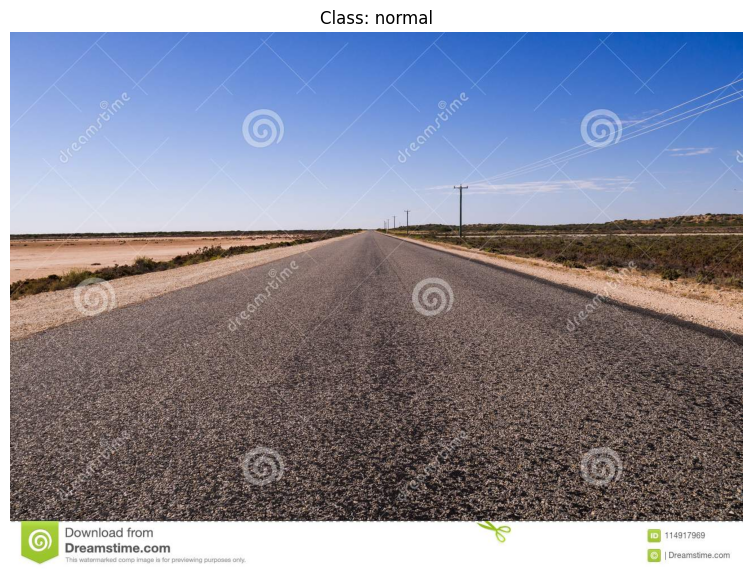

In [11]:
import random
from PIL import Image
image_path_list = list(normal_dir.glob("*.jpg"))

random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.title(f"Class: {image_class}")
plt.axis(False);

In [12]:
train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)), 
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [13]:
from torch.utils.data import random_split
from torchvision import datasets

In [14]:
full_dataset = datasets.ImageFolder(root=image_path)

print(f"Classes: {full_dataset.classes}")
print(f"Class To idx: {full_dataset.class_to_idx}")
print(f"Total imgs: {len(full_dataset)}")


Classes: ['normal', 'potholes']
Class To idx: {'normal': 0, 'potholes': 1}
Total imgs: 681


In [15]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, {train_size, test_size})

In [16]:
train_data.dataset.transform = train_transform
test_data.dataset.transform = test_transform

In [17]:
class_names = full_dataset.classes
class_dict = full_dataset.class_to_idx
#getting names and indexes for classes as dicts

In [18]:
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

In [19]:
img, label = next(iter(train_dataloader))
print(f"Image Shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label Shape: {label.shape}")

Image Shape: torch.Size([32, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label Shape: torch.Size([32])


In [20]:
import torchvision.models as models
import torch.nn as nn
def build_model(pretrained=True, fine_tune=True, num_classes=2):
    if pretrained:
        print('[INFO]: Loading pre-trained weights')
    else:
        print('[INFO]: Not loading pre-trained weights')
    model = models.efficientnet_b0(pretrained=pretrained)
    if fine_tune:
        print('[INFO]: Fine-tuning all layers...')
        for params in model.parameters():
            params.requires_grad = True
    elif not fine_tune:
        print('[INFO]: Freezing hidden layers...')
        for params in model.parameters():
            params.requires_grad = False
    # Change the final classification head.
    model.classifier[1] = nn.Linear(in_features=1280, out_features=num_classes)
    return model

In [25]:
import torch
import argparse
import torch.nn as nn
import torch.optim as optim
import time
from tqdm.auto import tqdm

# construct the argument parser
parser = argparse.ArgumentParser()
parser.add_argument(
    '-e', '--epochs', type=int, default=20,
    help='Number of epochs to train our network for'
)
parser.add_argument(
    '-pt', '--pretrained', action='store_true',
    help='Whether to use pretrained weights or not'
)
parser.add_argument(
    '-lr', '--learning-rate', type=float,
    dest='learning_rate', default=0.0001,
    help='Learning rate for training the model'
)
args = vars(parser.parse_args())


usage: colab_kernel_launcher.py [-h] [-e EPOCHS] [-pt] [-lr LEARNING_RATE]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-e1c9a7d7-189d-41f8-b0ae-fa23bc1318de.json


SystemExit: 2

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [21]:
def train(model, trainloader, optimizer, criterion):
    model.train()
    print('Training')
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    for i, data in tqdm(enumerate(trainloader), total=len(trainloader)):
        counter += 1
        image, labels = data
        image = image.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        # Forward pass.
        outputs = model(image)
        # Calculate the loss.
        loss = criterion(outputs, labels)
        train_running_loss += loss.item()
        # Calculate the accuracy.
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == labels).sum().item()
        # Backpropagation
        loss.backward()
        # Update the weights.
        optimizer.step()
    
    # Loss and accuracy for the complete epoch.
    epoch_loss = train_running_loss / counter
    epoch_acc = 100. * (train_running_correct / len(trainloader.dataset))
    return epoch_loss, epoch_acc

In [26]:
def validate(model, testloader, criterion):
    model.eval()
    print('Validation')
    valid_running_loss = 0.0
    valid_running_correct = 0
    counter = 0
    with torch.no_grad():
        for i, data in tqdm(enumerate(testloader), total=len(testloader)):
            counter += 1
            
            image, labels = data
            image = image.to(device)
            labels = labels.to(device)
            # Forward pass.
            outputs = model(image)
            # Calculate the loss.
            loss = criterion(outputs, labels)
            valid_running_loss += loss.item()
            # Calculate the accuracy.
            _, preds = torch.max(outputs.data, 1)
            valid_running_correct += (preds == labels).sum().item()
        
    # Loss and accuracy for the complete epoch.
    epoch_loss = valid_running_loss / counter
    epoch_acc = 100. * (valid_running_correct / len(testloader.dataset))
    return epoch_loss, epoch_acc

In [27]:
LEARNING_RATE = 1e-3
EPOCHS = 15
device = ('cuda' if torch.cuda.is_available() else 'cpu')


cpu


In [29]:
model = build_model(
        pretrained=True, 
        fine_tune=True, 
        num_classes=len(full_dataset.classes)
    ).to(device)

[INFO]: Loading pre-trained weights
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


[INFO]: Fine-tuning all layers...


In [31]:
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

4,010,110 total parameters.
4,010,110 training parameters.


In [32]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [33]:
criterion = nn.CrossEntropyLoss()

In [35]:
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
for epoch in range(EPOCHS):
    print(f"[INFO]: Epoch {epoch+1} of {EPOCHS}")
    train_epoch_loss, train_epoch_acc = train(model, train_dataloader, 
                                                optimizer, criterion)
    # valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
    #                                                 criterion)
    train_loss.append(train_epoch_loss)
    # valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    # valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    print('-'*50)
    time.sleep(5)

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/17 [00:00<?, ?it/s]

Training loss: 0.164, training acc: 94.301


NameError: name 'valid_epoch_loss' is not defined

In [36]:
print(train_loss)
print(train_acc)

[0.16369263499098666]
[94.30147058823529]


In [38]:

def test_model(model, test_dataloader, criterion, device):
    """
    Function to evaluate the trained model on the test set.
    """
    model.eval()  # switch to eval mode — disables dropout, freezes batchnorm stats
    model.to(device)

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # no gradient tracking needed — saves memory and compute
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # if using CrossEntropyLoss with 2 output neurons
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total * 100

    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")

    return avg_loss, accuracy

In [39]:

test_model(model,test_dataloader, criterion,device)

Test Loss: 0.1323
Test Accuracy: 96.35%


(0.13233289775187082, 96.35036496350365)

In [41]:
!pip install onnxscript --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 11.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 12.2 MB/s eta 0:00:00


In [43]:
model.eval()
dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    "best.onnx",
    input_names=["images"],
    output_names=["output"],
    dynamic_axes={
        "images": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    opset_version=17,
    dynamo=False   # ← bypasses onnxscript / dynamo entirely, avoids this bug
)

/tmp/ipykernel_58/3167183771.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [44]:
os.path.exists("/kaggle/working/best.onnx")

True

In [45]:
from IPython.display import FileLink
FileLink("best.onnx")

/kaggle/working/best.onnx

In [ ]:
#link to dataset:https://www.kaggle.com/datasets/atulyakumar98/pothole-detection-dataset